In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="PizzeriaDB",
    user="postgres",
    password="9446" 
)

items = pd.read_sql_query('SELECT * FROM items', conn)
orders = pd.read_sql_query('SELECT * FROM orders', conn)
orders["created_at"] = pd.to_datetime(orders["created_at"])

C:\Users\user\AppData\Local\Temp\ipykernel_12212\1933950547.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  items = pd.read_sql_query('SELECT * FROM items', conn)
C:\Users\user\AppData\Local\Temp\ipykernel_12212\1933950547.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql_query('SELECT * FROM orders', conn)
C:\Users\user\AppData\Local\Temp\ipykernel_12212\1933950547.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders["created_at"] = pd.to_datetime(orders["created_at"])


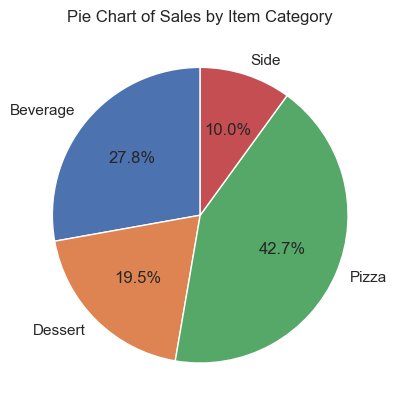

In [39]:
# Pie chart of Sales by Item Category
merged = orders.merge(items, on='item_id')
sizes = merged.groupby('item_category')['quantity'].sum()
labels = sizes.index
sizes = sizes.values

fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Pie Chart of Sales by Item Category")
plt.show()

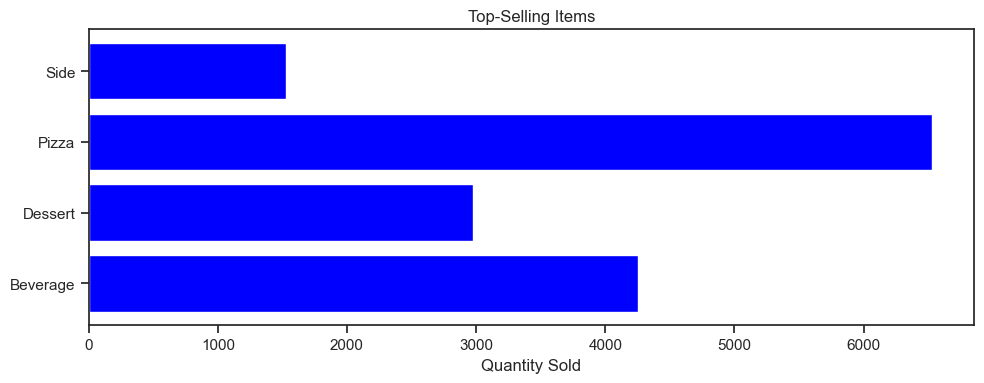

In [40]:
#Bar chart of Top-Selling Items
plt.figure(figsize=(10,4))
sns.set_theme(style="ticks")
items_sold=merged.groupby('item_category')['quantity']
plt.barh(items_sold.sum().index, items_sold.sum().values, color='blue')
plt.xlabel("Quantity Sold")
plt.ylabel("")
plt.title("Top-Selling Items")
plt.tight_layout()
plt.show()

TypeError: plot() got an unexpected keyword argument 'x'

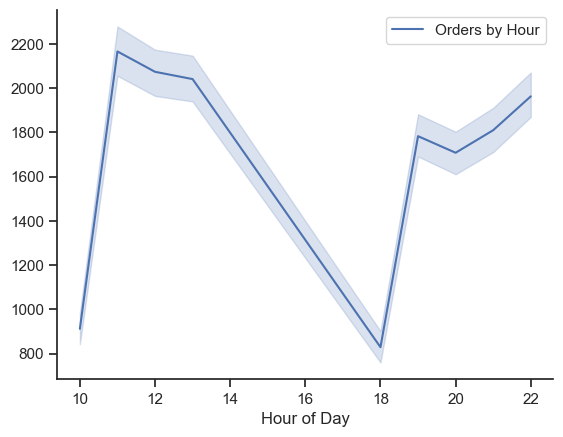

In [47]:
#Line chart of Orders by Hour and Sales by Hour
orders["hour"] = orders["created_at"].dt.hour

sns.lineplot(data=orders, x='hour', y='quantity', estimator='sum', label='Orders by Hour')
sns.set_theme(style="ticks")
sns.despine()
plt.xlabel("Hour of Day")
plt.ylabel("")
plt.plot(data=items, x=orders['hour'], y='item_price', color='grey', linewidth=0.8, alpha=0.2, estimator='sum', label='Sales by Hour')
plt.show()